# Simulating a 3D balanced SSFP acquisition

[`01_build.ipynb`](01_build.ipynb) writes two protocols -- a representative `192 x 192 x 16`
acquisition and a reduced one at the **same TR** -- each as a continuous and an interrupted
segmented file. It asserts that they are balanced, which is a statement about gradient waveforms.

**It is not a statement that the acquisition produces the image it is supposed to.** This notebook
answers the questions a waveform check cannot:

```text
1. what preparation should this protocol use, and why not the other one?
2. what did 01 actually write?
3. does the continuous acquisition reconstruct into the right volume?
4. what does interrupted segmentation change?
5. does it behave like bSSFP at all?
6. what remains a protocol choice?
```

Everything simulated here is a file `01` wrote. The reduced protocol is the one that is affordable
to simulate; it shares the representative protocol's preparation, phase cycle, view order,
segmentation rule and TR, and `01` writes it from the same functions so the relationship is
inspectable rather than asserted.

In [1]:
import os
import sys

#: MRzero's inner loop takes every core it is offered.  Hold it to four, before torch is imported.
SIM_THREADS = 4
for _var in ('OMP_NUM_THREADS', 'MKL_NUM_THREADS', 'RAYON_NUM_THREADS',
             'OPENBLAS_NUM_THREADS', 'NUMEXPR_NUM_THREADS'):
    os.environ[_var] = str(SIM_THREADS)

import contextlib
import os as _os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp
import torch

#: tqdm's auto-selector warns when ipywidgets is absent, which has nothing to do with this
#: notebook.  Suppressed at the import that raises it rather than globally.
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='IProgress not found')
    import MRzeroCore as mr0

import seqcraft as sc

torch.set_num_threads(SIM_THREADS)
#: 58 rather than a default 100: this notebook is committed with its figures, and the
#: repository refuses an added file over 512 KB.
plt.rcParams['figure.dpi'] = 58
#: The one warning this notebook deliberately silences, and only this one: several gradient axes
#: ramping together exceed the scalar per-axis norm while each amplifier axis stays within its own
#: limit.  01 counts these; repeating thousands of sites here would bury everything else.  Any
#: other warning is left visible on purpose.
warnings.filterwarnings('ignore', category=sc.SeqCraftWarning,
                        message='.*vector-norm limit.*')

sys.path.insert(0, str(Path('..').resolve()))
import phantom as ph            # noqa: E402 -- the shared BrainWeb preparation, one directory up

SEQ_DIR = Path('seq')
#: Diagnostics are not acquisitions: single locations read hundreds of times.  Their own directory,
#: so `seq/` holds only the four files 01 ships.
DIAG_DIR = SEQ_DIR / 'diagnostics'
DIAG_DIR.mkdir(parents=True, exist_ok=True)

#: The two brain volumes are the expensive part.  Every *number* below is measured on a single
#: voxel and runs either way.
BRAIN_IMAGES = True

nominal = np.load(SEQ_DIR / 'bssfp_3d_nominal.npz')
FOV_MM = tuple(float(v) for v in nominal['fov_mm'])
SLAB_MM, FLIP_DEG = float(nominal['slab_mm']), float(nominal['flip_deg'])
BANDWIDTH_HZ_PX = float(nominal['bandwidth_hz_px'])
RF_DURATION_S = float(nominal['rf_duration_s'])
PHASE_STEP, RAMP_STEPS = float(nominal['phase_step']), int(nominal['ramp_steps'])
SHOT_VIEWS, RECOVERY_S = int(nominal['shot_views']), float(nominal['recovery_s'])
RESTART_DUMMIES = int(nominal['restart_dummies'])

#: The representative acquisition, used for the transient and ordering physics below.
REP_MATRIX = tuple(int(v) for v in nominal['matrix'])
REP_TABLE = [tuple(int(v) for v in row) for row in nominal['table']]
REP_CENTER = (int(nominal['center_line']), int(nominal['center_partition']))

#: The reduced protocol is what gets simulated; the representative one is read back in section 2.
NX, NY, NZ = (int(v) for v in nominal['validation_matrix'])
TE_S, TR_S = float(nominal['validation_te_s']), float(nominal['validation_tr_s'])
TABLE = [tuple(int(v) for v in row) for row in nominal['validation_table']]
CENTER_LINE = int(nominal['validation_center_line'])
CENTER_PARTITION = int(nominal['validation_center_partition'])

print(f'representative  {tuple(int(v) for v in nominal["matrix"])}  '
      f'TE {float(nominal["te_s"]) * 1e3:.3f}  TR {float(nominal["tr_s"]) * 1e3:.3f} ms')
print(f'validation      {(NX, NY, NZ)}  TE {TE_S * 1e3:.3f}  TR {TR_S * 1e3:.3f} ms  '
      f'-- same TR: {abs(TR_S - float(nominal["tr_s"])) < 1e-12}')
print(f'preparation     {str(nominal["preparation"])}, {RAMP_STEPS} steps')
print(f'view order      {str(nominal["view_order"])}')
print(f'segmentation    every {SHOT_VIEWS} views, {RECOVERY_S * 1e3:.0f} ms recovery, '
      f'{RESTART_DUMMIES} restart dummies -- {len(REP_TABLE) // SHOT_VIEWS} shots '
      f'representative, {len(TABLE) // SHOT_VIEWS} validation')
print(f'budget          {torch.get_num_threads()} torch threads, '
      f'brain images {"on" if BRAIN_IMAGES else "off"}')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


representative  (192, 192, 16)  TE 2.104  TR 4.210 ms
validation      (48, 32, 8)  TE 2.100  TR 4.210 ms  -- same TR: True
preparation     linear flip-angle ramp, 24 steps
view order      bidirectional sequential, constant-kz lines
segmentation    every 53 views, 107 ms recovery, 8 restart dummies -- 57 shots representative, 4 validation
budget          4 torch threads, brain images on


In [2]:
opts = pp.Opts(
    max_grad=32, grad_unit='mT/m', max_slew=130, slew_unit='T/m/s', B0=3.0,
    rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6,
)


def kernel_at(flip_deg, tr_s=None):
    '''A repetition of the reduced protocol at `flip_deg`, pinned to the shared TR.'''
    return sc.modules.bSSFP3DTR(
        opts=opts, fov_mm=FOV_MM, matrix=(NX, NY, NZ), slab_thickness_mm=SLAB_MM,
        flip_deg=flip_deg, bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S,
        tr_s=TR_S if tr_s is None else tr_s,
    )


kernel = kernel_at(FLIP_DEG)
assert abs(kernel.tr_s - TR_S) < 1e-12 and abs(kernel.te_s - TE_S) < 1e-12
ECHO, SAMPLES = kernel.ro.echo_sample(0), int(kernel.ro.adc.num_samples)
NAV = pp.make_label(type='SET', label='NAV', value=1)


@contextlib.contextmanager
def quiet():
    '''Silence the solver's log: it is written to file descriptor 1 from Rust.'''
    saved, null = _os.dup(1), _os.open(_os.devnull, _os.O_WRONLY)
    try:
        _os.dup2(null, 1)
        yield
    finally:
        _os.dup2(saved, 1)
        _os.close(null)
        _os.close(saved)


def simulate_wide(path, obj, samples, *, states=200):
    '''One written .seq against `obj`; one row of `samples` per repetition.'''
    seq = mr0.Sequence.import_file(str(path))
    with quiet():
        graph = mr0.compute_graph(seq, obj, max_state_count=states, min_state_mag=1e-4)
        signal = mr0.execute_graph(graph, seq, obj, min_emitted_signal=1e-4,
                                   min_latent_signal=1e-5, print_progress=False)
    return np.asarray(signal.detach().cpu().numpy()).reshape(-1, samples)


def simulate(path, obj, *, states=200):
    return simulate_wide(path, obj, SAMPLES, states=states)


def voxel(T1, T2, B0=0.0, size_m=0.001):
    '''One small box.  Small matters in section 4, where its own k-space must be flat.'''
    return mr0.CustomVoxelPhantom(pos=[[0.0, 0.0, 0.0]], PD=1.0, T1=T1, T2=T2, T2dash=1e3,
                                  D=0.0, B0=B0, voxel_size=size_m, voxel_shape='box').build()


TISSUES = {'white matter': dict(T1=0.83, T2=0.080),
           'grey matter':  dict(T1=1.33, T2=0.110),
           'CSF':          dict(T1=4.00, T2=2.000)}
NULL_HZ = 1.0 / (2 * TR_S)
print(f'echo sample {ECHO} of {SAMPLES}; band edge (null) at {NULL_HZ:.0f} Hz')

echo sample 24 of 48; band edge (null) at 119 Hz


## 1. What preparation should this protocol use?

### First: what a preparation can and cannot do

Hargreaves et al. (2001) write one repetition as a discrete-time system, `M(k+1) = A M(k) + B`.
Subtracting the fixed point gives `Q(k+1) = A Q(k)` for the error `Q = M - M_ss`, so the approach to
steady state is the zero-input response of a third-order linear system and **decays at the
eigenvalues of `A`**.

That matters for what follows: `A` is built from T1, T2, TR, the flip angle and off-resonance. A
preparation pulse changes the *initial* error `Q(0)`. It does not touch `A`, so it cannot change
the rate. What it can do -- and the reason catalyzation is worth doing -- is start the train with a
smaller error, so the signal falls inside a useful tolerance earlier.

`A` is cheap to write down, so the rate can be computed rather than inferred from a finite
simulation.

In [3]:
def rot_x(a):
    c, s = np.cos(a), np.sin(a)
    return np.array([[1, 0, 0], [0, c, -s], [0, s, c]])


def rot_z(p):
    c, s = np.cos(p), np.sin(p)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])


def transfer(T1, T2, df_hz=0.0, flip_deg=FLIP_DEG, tr_s=TR_S, phase_step=PHASE_STEP):
    '''Hargreaves Eq. [1]: precession and relaxation over TR, then the RF rotation.

    The 0/pi RF alternation is folded into the precession as an extra pi per TR, which is the
    same equivalence the Handbook states for sign-alternated bSSFP.
    '''
    E1, E2 = np.exp(-tr_s / T1), np.exp(-tr_s / T2)
    theta = 2 * np.pi * df_hz * tr_s + np.deg2rad(phase_step)
    R = rot_x(np.deg2rad(flip_deg))
    return R @ np.diag([E2, E2, E1]) @ rot_z(theta), R @ np.array([0, 0, 1 - E1])


print(f'{"tissue":14s}{"|lambda| max":>14s}{"reps / e":>10s}{"seconds / e":>13s}'
      f'{"reps to 5%":>12s}{"to 1%":>8s}')
DECAY = {}
for name, t in TISSUES.items():
    A, _ = transfer(**t)
    lam = np.abs(np.linalg.eigvals(A)).max()
    DECAY[name] = lam
    tau = -1 / np.log(lam)
    print(f'{name:14s}{lam:14.5f}{tau:10.1f}{tau * TR_S:13.3f}'
          f'{np.log(0.05) / np.log(lam):12.0f}{np.log(0.01) / np.log(lam):8.0f}')
print()
print('These are properties of the repetition, not of any preparation.  They also set how long a')
print('train has to run before its tail can honestly be called a steady state.')

tissue          |lambda| max  reps / e  seconds / e  reps to 5%   to 1%
white matter         0.98804      83.1        0.350         249     383
grey matter          0.99173     120.4        0.507         361     554
CSF                  0.99879     828.8        3.489        2483    3817

These are properties of the repetition, not of any preparation.  They also set how long a
train has to run before its tail can honestly be called a steady state.


### Then: which preparation, measured where it matters

The two named schemes are `alpha/2 - TR/2` and a linear flip-angle ramp. Comparing them **only on
resonance** would not settle anything: bSSFP is run with a passband of finite width, tissue spans
it, and the `alpha/2` pulse is non-selective -- Hargreaves' analysis is that such a pulse rotates
magnetisation toward the steady state for part of the frequency range and away from it for the
rest. So the comparison below sweeps off-resonance from the passband centre toward the band edge.

`REPS` is set from the table above: white matter reaches 1% of its steady state in about 380
repetitions, so a 450-repetition train has a tail that can be used as a reference.

In [4]:
REPS = 450


def half_angle_block(flip_deg):
    exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg / 2, thickness_mm=SLAB_MM,
                                duration_s=0.5e-3)
    a_post = -exc.rephaser_area_per_m
    a_pre = float(exc.gz.area) - a_post
    lead = pp.make_trapezoid(channel='z', area=-a_pre, system=opts)
    lead_s = float(pp.calc_duration(lead))
    out = sc.LogicBlock('alpha_over_2')
    out.add(0.0, lead)
    out.add(lead_s, exc(rephase=True))
    return out, lead_s + exc.time_to_center()


def transient_file(path, prep, *, reps=REPS, b1=1.0):
    '''`reps` repetitions at the centre of k-space after `prep`; returns the first imaging index.'''
    k = kernel_at(FLIP_DEG * b1)
    out, at, n, first = sc.LogicBlock('transient'), 0.0, 0, 0
    if prep == 'alpha/2':
        block, to_centre = half_angle_block(FLIP_DEG * b1)
        out.add(0.0, block)
        at = sc.Raster(opts.grad_raster_time).ceil(to_centre + TR_S / 2 - k.time_to_rf_center())
        n = 1                       # the alpha/2 pulse takes the first slot in the alternation
    elif isinstance(prep, int):
        for j in range(prep):
            r = kernel_at(FLIP_DEG * b1 * (j + 1) / (prep + 1))
            out.add(at, r(line=CENTER_LINE, partition=CENTER_PARTITION, phase_deg=PHASE_STEP * n))
            out.add(at, NAV)
            at, n, first = at + r.tr_s, n + 1, first + 1
    for _ in range(reps):
        out.add(at, k(line=CENTER_LINE, partition=CENTER_PARTITION, phase_deg=PHASE_STEP * n))
        out.add(at, NAV)
        at, n = at + TR_S, n + 1
    sc.compile(out, opts, name=path.stem).write(str(path))
    return first, k


def peak_transient(path, first, k, df=0.0, tissue='white matter', window=60):
    '''Largest |deviation| in the first `window` imaging repetitions, over the late-train level.'''
    rows = simulate(path, voxel(B0=df, **TISSUES[tissue]))
    s = np.abs(rows[first:, k.ro.echo_sample(0)])
    late = s[-40:].mean()
    return np.abs(s[:window] - late).max() / late, s / late


CANDIDATES = {'none': ('none', 'prep_none'),
              'alpha/2 - TR/2': ('alpha/2', 'prep_alpha_over_2'),
              f'{RAMP_STEPS}-step ramp': (RAMP_STEPS, f'prep_ramp{RAMP_STEPS}')}
BUILT = {name: transient_file(DIAG_DIR / f'{stem}.seq', prep)
         for name, (prep, stem) in CANDIDATES.items()}

offsets = [0.0, 0.5 * NULL_HZ, 0.75 * NULL_HZ, 0.9 * NULL_HZ]
print('peak transient over the first 60 imaging repetitions, / late-train signal (white matter)')
print(f'{"preparation":18s}' + ''.join(f'{f"{o:.0f} Hz":>11s}' for o in offsets))
CURVES = {}
for name, (prep, stem) in CANDIDATES.items():
    first, k = BUILT[name]
    cells = []
    for o in offsets:
        peak, curve = peak_transient(DIAG_DIR / f'{stem}.seq', first, k, df=o)
        cells.append(f'{peak:11.2f}')
        if o == 0.0:
            CURVES[name] = curve
    print(f'{name:18s}' + ''.join(cells))

/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_13409/3086100621.py:36: SeqCraftWarning: 1 same-axis gradient merge: transient.alpha_over_2.Excitation (axis z)
  sc.compile(out, opts, name=path.stem).write(str(path))


peak transient over the first 60 imaging repetitions, / late-train signal (white matter)
preparation              0 Hz      59 Hz      89 Hz     107 Hz


none                     3.59       5.31      10.41      25.24


alpha/2 - TR/2           1.53       3.59       9.55      24.71


24-step ramp             1.45       2.55       5.82      10.80


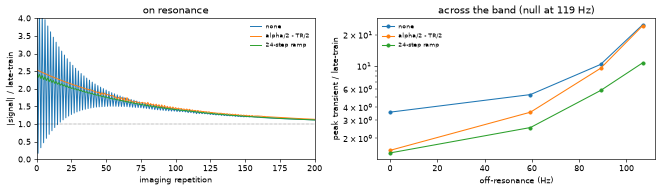

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for name, curve in CURVES.items():
    axes[0].plot(curve, lw=1.2, label=name)
axes[0].axhline(1.0, color='k', lw=0.6, ls=':')
axes[0].set(xlabel='imaging repetition', ylabel='|signal| / late-train',
            title='on resonance', xlim=(0, 200), ylim=(0, 4))
axes[0].legend(fontsize=7, frameon=False)

for name, (prep, stem) in CANDIDATES.items():
    first, k = BUILT[name]
    sweep = [peak_transient(DIAG_DIR / f'{stem}.seq', first, k, df=o)[0]
             for o in offsets]
    axes[1].plot(offsets, sweep, 'o-', lw=1.3, ms=4, label=name)
axes[1].set(xlabel='off-resonance (Hz)', ylabel='peak transient / late-train',
            title=f'across the band (null at {NULL_HZ:.0f} Hz)', yscale='log')
axes[1].legend(fontsize=7, frameon=False)
fig.tight_layout()

In [6]:
print('B1 robustness at the passband centre, same metric:')
print(f'{"preparation":18s}' + ''.join(f'{f"B1 x{b:.2f}":>11s}' for b in (0.9, 1.0, 1.1)))
for name, (prep, stem) in CANDIDATES.items():
    cells = []
    for b1 in (0.9, 1.0, 1.1):
        path = DIAG_DIR / f'{stem}_b1{int(b1 * 100)}.seq'
        first, k = transient_file(path, prep, b1=b1)
        cells.append(f'{peak_transient(path, first, k)[0]:11.2f}')
    print(f'{name:18s}' + ''.join(cells))

B1 robustness at the passband centre, same metric:
preparation          B1 x0.90   B1 x1.00   B1 x1.10


none                     3.10       3.59       4.16


/var/folders/16/qs6slfs1615_9cf889mc198c0000gn/T/ipykernel_13409/3086100621.py:36: SeqCraftWarning: 1 same-axis gradient merge: transient.alpha_over_2.Excitation (axis z)
  sc.compile(out, opts, name=path.stem).write(str(path))


alpha/2 - TR/2           1.23       1.53       1.89


24-step ramp             1.17       1.45       1.77


### How long a ramp

`01` ships 24 steps. That number comes from here: lengthening the ramp keeps improving the
band-edge transient with clearly diminishing returns, and the cost is repetitions that acquire
nothing.

ramp steps        0 Hz    107 Hz   cost (reps)


8                 1.69     20.30             8


16                1.53     15.86            16


24                1.45     10.80            24


32                1.39      9.90            32


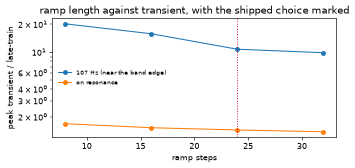

In [7]:
RAMP_SWEEP = (8, 16, 24, 32)
edge = 0.9 * NULL_HZ
print(f'{"ramp steps":12s}{"0 Hz":>10s}{f"{edge:.0f} Hz":>10s}{"cost (reps)":>14s}')
ramp_sweep = {}
for n in RAMP_SWEEP:
    path = DIAG_DIR / f'prep_ramp{n}.seq'
    first, k = transient_file(path, n)
    on = peak_transient(path, first, k)[0]
    off = peak_transient(path, first, k, df=edge)[0]
    ramp_sweep[n] = (on, off)
    print(f'{n:<12d}{on:10.2f}{off:10.2f}{n:14d}')

fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.plot(RAMP_SWEEP, [ramp_sweep[n][1] for n in RAMP_SWEEP], 'o-', lw=1.3, ms=5,
        label=f'{edge:.0f} Hz (near the band edge)')
ax.plot(RAMP_SWEEP, [ramp_sweep[n][0] for n in RAMP_SWEEP], 'o-', lw=1.3, ms=5,
        label='on resonance')
ax.axvline(RAMP_STEPS, color='crimson', ls=':', lw=1.2)
ax.set(xlabel='ramp steps', ylabel='peak transient / late-train', yscale='log',
       title='ramp length against transient, with the shipped choice marked')
ax.legend(fontsize=8, frameon=False)
fig.tight_layout()

### What that settles

**On resonance the two schemes are equivalent, and across the band they are not.** The `alpha/2`
pulse holds its advantage near the passband centre and loses it toward the edge; the ramp degrades
more slowly. That is the behaviour Hargreaves predicts for a non-selective half-angle pulse, and it
is the reason `01` ships the ramp.

**B1 does not separate them.** Both stay close to their nominal behaviour over `+-10%`, because in
both schemes every preparation pulse scales with the same B1 as the imaging pulses.

What neither of them does is change the decay rate. The curves on the left all approach the same
asymptote on the same timescale -- the eigenvalue from the previous section -- they simply start
closer to or further from it.

**CSF is excluded from any "repetitions to settle" claim here.** Its eigenvalue implies about 2500
repetitions to reach 5%, which is far beyond this train, so the tail of a 450-repetition CSF
simulation is not a steady state and must not be used as one.

## 2. What did `01` actually write?

`01` already asserts the artifact contract as it writes the files, and that check runs in
continuous integration. What is useful here is the acquisition *structure*: which views each file
visits, in what order, and where the centre of k-space falls relative to each ramp.

In [8]:
for stem in ('bssfp_3d', 'bssfp_3d_segmented', 'bssfp_3d_segmented_restart',
             'bssfp_3d_validation', 'bssfp_3d_validation_segmented',
             'bssfp_3d_validation_segmented_restart'):
    seq = pp.Sequence()
    seq.read(str(SEQ_DIR / f'{stem}.seq'))
    adcs = sum(1 for i in range(1, len(seq.block_events) + 1)
               if getattr(seq.get_block(i), 'adc', None) is not None)
    print(f'{stem:34s} {adcs:5d} readouts  {seq.duration()[0]:7.2f} s  '
          f'TR {float(seq.definitions["TR"]) * 1e3:.3f} ms')
print()
print(f'the three validation files are what gets reconstructed as a volume; the representative '
      f'three are the same policy at {tuple(int(v) for v in nominal["matrix"])}, and section 4 '
      f'measures those')

bssfp_3d                            3072 readouts    13.03 s  TR 4.210 ms


bssfp_3d_segmented                  3072 readouts    19.13 s  TR 4.210 ms


bssfp_3d_segmented_restart          3072 readouts    21.05 s  TR 4.210 ms
bssfp_3d_validation                  256 readouts     1.18 s  TR 4.210 ms
bssfp_3d_validation_segmented        256 readouts     1.61 s  TR 4.210 ms
bssfp_3d_validation_segmented_restart   256 readouts     1.74 s  TR 4.210 ms

the three validation files are what gets reconstructed as a volume; the representative three are the same policy at (192, 192, 16), and section 4 measures those


largest |ky| step between consecutive acquired views: 1
centre of k-space is view 144 of 256, 38 views into shot 2
01 measures the step over the whole RF train, including out of the ramp; this plot is
the acquired-view subset only.


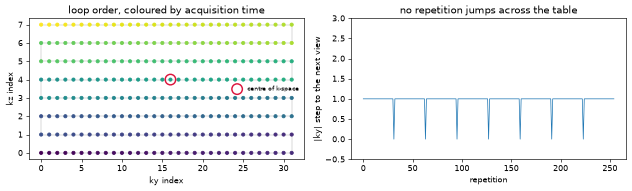

In [9]:
order = np.array(TABLE)
centre_at = TABLE.index((CENTER_LINE, CENTER_PARTITION))

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.4))
axes[0].plot(order[:, 0], order[:, 1], lw=0.6, color='0.7', zorder=1)
axes[0].scatter(order[:, 0], order[:, 1], c=np.arange(len(order)), cmap='viridis', s=16, zorder=2)
axes[0].scatter([CENTER_LINE], [CENTER_PARTITION], facecolors='none', edgecolors='crimson',
                s=170, lw=1.8, label='centre of k-space')
axes[0].set(xlabel='ky index', ylabel='kz index',
            title='loop order, coloured by acquisition time')
axes[0].legend(fontsize=7, frameon=False)

steps = np.abs(np.diff(order[:, 0]))
axes[1].plot(steps, lw=0.9)
axes[1].set(xlabel='repetition', ylabel='|ky| step to the next view',
            title='no repetition jumps across the table', ylim=(-0.5, max(3, steps.max() + 0.5)))
fig.tight_layout()

print(f'largest |ky| step between consecutive acquired views: {steps.max()}')
print(f'centre of k-space is view {centre_at} of {len(TABLE)}, '
      f'{centre_at % SHOT_VIEWS} views into shot {centre_at // SHOT_VIEWS}')
print('01 measures the step over the whole RF train, including out of the ramp; this plot is')
print('the acquired-view subset only.')

## 3. Does the continuous acquisition reconstruct correctly?

A 3D FFT of the sorted table. The three matrix dimensions are all different, so a `ky`/`kz` swap or
a transposed reconstruction changes the **shape** of the volume rather than producing a plausible
image.

sequence encoded FOV        300 x 300 x 96 mm
sequence excited slab       80 mm
phantom physical extent     192 x 192 x 96 mm
phantom matrix              (48, 32, 8)
simulation voxel            4.0 x 6.0 x 12.0 mm
image pixel                 6.2 x 9.4 x 12.0 mm



volume (48, 32, 8), peak at (np.int64(21), np.int64(13), np.int64(4))


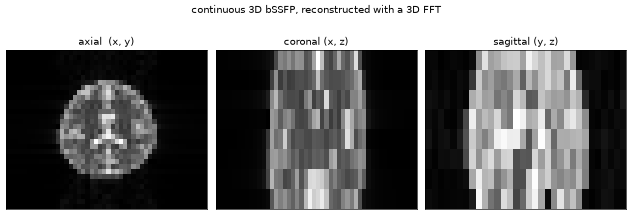

In [10]:
def reconstruct(rows):
    '''Sort repetitions into (kx, ky, kz) and take the 3D FFT.

    The table's indices are zero-based with DC at `matrix // 2`, which is the order `ifftshift`
    expects -- the centre convention the modules use is the one this assumes.
    '''
    cube = np.zeros((NX, NY, NZ), dtype=complex)
    for row, (line, partition) in enumerate(TABLE):
        cube[:, line, partition] = rows[row]
    return cube, np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(cube)))


def three_planes(volume, title):
    fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.6))
    for ax, (name, plane) in zip(axes, (
            ('axial  (x, y)', volume[:, :, NZ // 2].T),
            ('coronal (x, z)', volume[:, NY // 2, :].T),
            ('sagittal (y, z)', volume[NX // 2, :, :].T))):
        ax.imshow(plane, cmap='gray', origin='lower', aspect='auto')
        ax.set(title=name, xticks=[], yticks=[])
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


if BRAIN_IMAGES:
    # `slab_3d`, not `slab`: the 2D helper returns NZ *native* slices, which at NZ = 8 is 12 mm
    # of anatomy inside a sequence that encodes 96 mm.  This one covers the encoded extent and
    # samples it at NZ voxels, which is a deliberately coarse phantom and a correct one.
    brain = ph.slab_3d(matrix=(NX, NY, NZ), z_extent_mm=FOV_MM[2], n_coils=0)
    ex = ph.extent_mm(brain)
    print(f'sequence encoded FOV        {FOV_MM[0]:.0f} x {FOV_MM[1]:.0f} x {FOV_MM[2]:.0f} mm')
    print(f'sequence excited slab       {SLAB_MM:.0f} mm')
    print(f'phantom physical extent     {ex[0]:.0f} x {ex[1]:.0f} x {ex[2]:.0f} mm')
    print(f'phantom matrix              {tuple(brain.PD.shape)}')
    print(f'simulation voxel            {ex[0] / NX:.1f} x {ex[1] / NY:.1f} x {ex[2] / NZ:.1f} mm')
    print(f'image pixel                 {FOV_MM[0] / NX:.1f} x {FOV_MM[1] / NY:.1f} x '
          f'{FOV_MM[2] / NZ:.1f} mm')

    assert abs(ex[2] - FOV_MM[2]) < 1.0, 'the phantom must span the encoded z extent'
    assert ex[0] <= FOV_MM[0] + 1 and ex[1] <= FOV_MM[1] + 1, 'and must fit inside the FOV'
    assert SLAB_MM < ex[2], 'the excited slab must sit inside the encoded extent'

    rows_cont = simulate(SEQ_DIR / 'bssfp_3d_validation.seq', brain.build())
    k_cont, vol_cont = reconstruct(rows_cont)
    three_planes(np.abs(vol_cont), 'continuous 3D bSSFP, reconstructed with a 3D FFT')
    print()
    print(f'volume {vol_cont.shape}, peak at '
          f'{np.unravel_index(np.argmax(np.abs(vol_cont)), vol_cont.shape)}')
else:
    print('BRAIN_IMAGES is off -- skipping the volume simulations')

The volume is `(48, 32, 8)`: readout, phase encode, partition. The sagittal plane is `32 x 8` and
visibly coarse along `z`, which is the geometry this reduced protocol asked for rather than an
artifact -- the representative protocol encodes the same slab with 16 partitions over a finer
in-plane matrix.

**This is what the reduced protocol is for**: geometry, orientation and the reconstruction itself.
The transient and ordering physics in the next section is measured on the representative files
instead, because a point-object history of those is cheap and the surrogate would be answering a
question about a different acquisition.

## 4. Segmentation: why, what it costs, and what can be done about it

### Why segment at all

Not to shorten the acquisition -- the restart preparation below is pure overhead on top of it.
Segmentation exists because an acquisition sometimes **has to fit into repeated short temporal
windows**. Morita et al. (2008) give the reason in the literature's own terms: k-space segmentation
is "utilized for acquiring electrocardiogram (ECG) gating images in a short period of time in the
cardiovascular area", and is "strictly no longer steady state, but contains a transient-state
contrast because it splits the sequence of RF pulses that are initially excited continuously for
the steady state". Cardiac cine is the canonical case -- only part of a cardiac phase's data fits
in one heartbeat, so a frame is assembled across heartbeats -- and breath-held abdominal work and
magnetisation-prepared acquisitions have the same shape.

```text
segmentation buys    one k-space acquisition distributed over repeated short imaging
                     windows -- gating, breath-holds, prepared contrast

segmentation costs   repeated interruption of the periodic state,
                     a restart transient at the start of every shot,
                     and whatever repetitions the restart policy spends
```

### The three trains `01` writes

All three walk the same table in the same order, at the same TR:

```text
A  continuous            one opening ramp, then every view, never interrupted

B  segmented             shots of 53 views separated by 107 ms, with acquisition resuming
                         immediately -- NO re-catalyzation of any kind after an interruption

C  segmented + restart   the same, with 8 full-flip repetitions after each interruption
                         before acquisition resumes
```

B is deliberately kept, because it is a real failure mode and a real clinical configuration.
Morita et al. (2008, p.1245) report that for their 3D segmented trueFISP "a dummy pulse was not
used for this sequence in both orderings when not using fat saturation", and that the 107 ms
inter-shot delay was "equivalent to a time of 28 RF pulses, which split the steady state".

### Two different questions, two different measurements

Interrupting the train does something to the **magnetisation**, and that may or may not become
visible **structure in the image**. Those are separate, and conflating them is how the earlier
drafts of this section went wrong.

```text
how far the state wanders      |echo| per acquired repetition against a point at the origin.
                               A point at the origin has flat k-space by construction, so any
                               variation across repetitions is the acquisition's transient and
                               not the object.  Encoding-independent.

what reaches the image         the reconstructed point response.  This depends additionally on
                               WHERE in the k-space table the wandering repetitions fall.
```

The image measurement needs a point whose own Fourier envelope is flat across the sampled table,
otherwise the object's transform is read as the acquisition's. The representative table reaches
further than the reduced one, so the condition is checked rather than assumed.

In [11]:
POINT_MM = 0.1
kmax = np.array([(REP_MATRIX[i] // 2) / (FOV_MM[i] * 1e-3) for i in range(3)])
envelope = float(np.prod(np.sinc(kmax * POINT_MM * 1e-3)))
print(f'|k|max per axis: ' + ', '.join(f'{v:.0f}' for v in kmax) + ' 1/m')
print(f'a {POINT_MM} mm box first nulls at {1 / (POINT_MM * 1e-3):.0f} 1/m')
print(f'its envelope at the far corner of the sampled table: {envelope:.4f}')
assert envelope > 0.99, 'the point object is not flat enough to call its k-space the acquisition'
print(f'-> flat to better than 1%, so what is measured is the acquisition')
print(f'   a 1 mm box would fall to {float(np.prod(np.sinc(kmax * 1e-3))):.2f} there, and would '
      f'report its own transform')

|k|max per axis: 320, 320, 83 1/m
a 0.1 mm box first nulls at 10000 1/m
its envelope at the far corner of the sampled table: 0.9965
-> flat to better than 1%, so what is measured is the acquisition
   a 1 mm box would fall to 0.70 there, and would report its own transform


In [12]:
REP_NX, REP_NY, REP_NZ = REP_MATRIX
rep_kernel = sc.modules.bSSFP3DTR(
    opts=opts, fov_mm=FOV_MM, matrix=REP_MATRIX, slab_thickness_mm=SLAB_MM, flip_deg=FLIP_DEG,
    bandwidth_hz_px=BANDWIDTH_HZ_PX, rf_duration_s=RF_DURATION_S)
REP_ECHO = int(rep_kernel.ro.echo_sample(0))


def point(df=0.0, size_mm=POINT_MM, tissue='white matter'):
    return mr0.CustomVoxelPhantom(
        pos=[[0.0, 0.0, 0.0]], PD=1.0, D=0.0, T2dash=1e3, B0=float(df),
        voxel_size=size_mm * 1e-3, voxel_shape='box', **TISSUES[tissue],
    ).build()


def echo_train(path, df=0.0, samples=None, echo=None, tissue='white matter'):
    '''|echo| for every acquired repetition, over its own late-train median.'''
    rows = simulate_wide(path, point(df, tissue=tissue), REP_NX if samples is None else samples)
    s = np.abs(rows[:, REP_ECHO if echo is None else echo])
    return s / np.median(s[-200:])


def point_response(path, df=0.0, states=200):
    '''The reconstructed point: the y profile through it, normalised to its peak.'''
    rows = simulate_wide(path, point(df), REP_NX, states=states)
    cube = np.zeros((REP_NX, REP_NY, REP_NZ), dtype=complex)
    for row, (line, partition) in enumerate(REP_TABLE):
        cube[:, line, partition] = rows[row]
    image = np.abs(np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(cube))))
    prof = image[REP_NX // 2, :, REP_NZ // 2]
    return prof / prof.max()


def far_response(prof):
    '''Summed and largest normalised magnitude away from the point itself.'''
    centre = len(prof) // 2
    far = np.array([prof[i] for i in range(len(prof)) if abs(i - centre) > 1])
    return far.sum(), far.max()

In [13]:
CASES = {'A continuous': 'bssfp_3d',
         'B segmented, no restart': 'bssfp_3d_segmented',
         f'C segmented, {RESTART_DUMMIES} restart dummies': 'bssfp_3d_segmented_restart'}
TRAIN, PROFILE = {}, {}
print(f'{"":34s}{"-- state --":>22s}{"-- image --":>21s}')
print(f'{"case":34s}{"min/level":>11s}{"rms dev":>11s}{"far sum":>11s}{"max far":>10s}')
for label, stem in CASES.items():
    TRAIN[label] = t = echo_train(SEQ_DIR / f'{stem}.seq')
    PROFILE[label] = p = point_response(SEQ_DIR / f'{stem}.seq')
    fs, fm = far_response(p)
    print(f'{label:34s}{t.min():11.3f}{np.sqrt(np.mean((t - 1) ** 2)):11.4f}'
          f'{fs:11.3f}{fm:10.4f}')

                                             -- state --          -- image --
case                                min/level    rms dev    far sum   max far


A continuous                            0.999     0.1642      0.100    0.0055


B segmented, no restart                 0.316     0.3445      0.223    0.0056


C segmented, 8 restart dummies          0.499     0.2666      0.206    0.0060


summed far response at 200 states 0.2234, at 400 states 0.2235 -- 0.05% apart


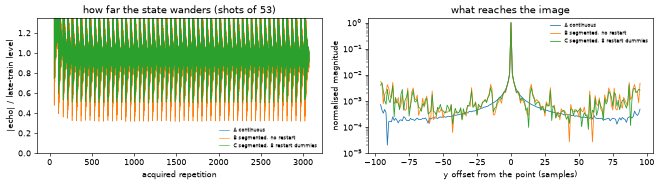

In [14]:
#: Every number in this section rests on 200 coherence states being enough for this train and
#: this tissue.  That is an assumption about the simulator, not about the acquisition, so it is
#: checked on the hardest case here -- the longest train, interrupted -- rather than assumed.
#: The tissue sweep later in the section shows what it looks like when it does not hold.
_far_200 = far_response(PROFILE['B segmented, no restart'])[0]
_far_400 = far_response(point_response(SEQ_DIR / 'bssfp_3d_segmented.seq', states=400))[0]
print(f'summed far response at 200 states {_far_200:.4f}, at 400 states {_far_400:.4f} '
      f'-- {abs(_far_400 - _far_200) / _far_200:.2%} apart')
assert abs(_far_400 - _far_200) / _far_200 < 0.02, '200 states is not enough for this measurement'

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.3))
for label, t in TRAIN.items():
    axes[0].plot(t, lw=0.7, label=label)
axes[0].set(xlabel='acquired repetition', ylabel='|echo| / late-train level',
            title=f'how far the state wanders (shots of {SHOT_VIEWS})', ylim=(0, 1.35))
axes[0].legend(fontsize=6.5, frameon=False, loc='lower right')

for label, p in PROFILE.items():
    axes[1].plot(np.arange(REP_NY) - REP_NY // 2, p, lw=1.0, label=label)
axes[1].set(xlabel='y offset from the point (samples)', ylabel='normalised magnitude',
            yscale='log', ylim=(1e-5, 1.5), title='what reaches the image')
axes[1].legend(fontsize=6.5, frameon=False)
fig.tight_layout()

### Can the interruption be mitigated?

The restart repetitions are not a replay of the opening ramp. After a 107 ms gap the magnetisation
is not where it was before the first pulse of the whole acquisition -- it has relaxed from a
driven state, not from equilibrium -- so a ramp designed to carry equilibrium magnetisation into
the periodic state is solving a different problem. What case C plays instead is full-flip
repetitions at the encoding of the view that is about to be acquired, which is the same thing the
train does on either side of the gap and keeps the phase-encode step across the restart small.

How many is a free parameter, so it is swept rather than asserted.

In [15]:
#: 01 owns the authoring; this rebuilds the same policy so one parameter can be swept.  The guard
#: below is what keeps the two from drifting: at the shipped setting it must reproduce 01's file.
RAMP = [sc.modules.bSSFP3DTR(
            opts=opts, fov_mm=FOV_MM, matrix=REP_MATRIX, slab_thickness_mm=SLAB_MM,
            flip_deg=FLIP_DEG * (k + 1) / (RAMP_STEPS + 1), bandwidth_hz_px=BANDWIDTH_HZ_PX,
            rf_duration_s=RF_DURATION_S, tr_s=rep_kernel.tr_s)
        for k in range(RAMP_STEPS)]


def segmented_train(path, *, shot_views, restart, table=None):
    table = REP_TABLE if table is None else table
    first_line, first_partition = table[0]
    tree, at, n = sc.LogicBlock('sweep'), 0.0, 0
    for rep in RAMP:
        tree.add(at, rep(line=first_line, partition=first_partition,
                         phase_deg=PHASE_STEP * n, acquire=False))
        at, n = at + rep.tr_s, n + 1
    for i, (line, partition) in enumerate(table):
        if i > 0 and i % shot_views == 0:
            at = sc.Raster(opts.grad_raster_time).ceil(at + RECOVERY_S)
            for _ in range(restart):
                tree.add(at, rep_kernel(line=line, partition=partition,
                                        phase_deg=PHASE_STEP * n, acquire=False))
                at, n = at + rep_kernel.tr_s, n + 1
        tree.add(at, rep_kernel(line=line, partition=partition, phase_deg=PHASE_STEP * n))
        at, n = at + rep_kernel.tr_s, n + 1
    sc.compile(tree, opts, name=path.stem).write(str(path))
    return path


def shape_of(path):
    seq = pp.Sequence()
    seq.read(str(path))
    adcs = sum(1 for i in range(1, len(seq.block_events) + 1)
               if getattr(seq.get_block(i), 'adc', None) is not None)
    return adcs, len(seq.block_events), round(seq.duration()[0], 6)


mine = shape_of(segmented_train(DIAG_DIR / 'check.seq',
                                shot_views=SHOT_VIEWS, restart=RESTART_DUMMIES))
theirs = shape_of(SEQ_DIR / 'bssfp_3d_segmented_restart.seq')
assert mine == theirs, f'this builder has drifted from 01: {mine} != {theirs}'
print(f'builder reproduces 01 at ({SHOT_VIEWS}, {RESTART_DUMMIES}): '
      f'{mine[0]} readouts, {mine[1]} blocks, {mine[2]:.3f} s')

builder reproduces 01 at (53, 8): 3072 readouts, 24921 blocks, 21.053 s


In [16]:
SWEEP = (0, 4, 8, 16, 24)
shots = (len(REP_TABLE) - 1) // SHOT_VIEWS
SHIPPED = {0: 'B segmented, no restart', RESTART_DUMMIES: list(CASES)[2]}
rows = {}
print(f'{"restart":>8s}{"extra reps":>12s}{"overhead":>10s}{"min/level":>12s}'
      f'{"rms dev":>10s}{"far sum":>10s}{"max far":>10s}')
for n in SWEEP:
    if n in SHIPPED:                          # already simulated above, same policy
        t, prof = TRAIN[SHIPPED[n]], PROFILE[SHIPPED[n]]
    else:
        p = segmented_train(DIAG_DIR / f'restart{n}.seq', shot_views=SHOT_VIEWS, restart=n)
        t, prof = echo_train(p), point_response(p)
    fs, fm = far_response(prof)
    rows[n] = (t.min(), np.sqrt(np.mean((t - 1) ** 2)), fs, fm)
    extra = shots * n
    print(f'{n:>8d}{extra:>12d}{extra / len(REP_TABLE) * 100:9.0f}%'
          f'{t.min():12.3f}{rows[n][1]:10.4f}{fs:10.3f}{fm:10.4f}')
cont = TRAIN['A continuous']
print(f'{"continuous":>8s}{0:>12d}{0:9d}%{cont.min():12.3f}'
      f'{np.sqrt(np.mean((cont - 1) ** 2)):10.4f}'
      f'{far_response(PROFILE["A continuous"])[0]:10.3f}'
      f'{far_response(PROFILE["A continuous"])[1]:10.4f}')

 restart  extra reps  overhead   min/level   rms dev   far sum   max far
       0           0        0%       0.316    0.3445     0.223    0.0056


       4         228        7%       0.420    0.3006     0.218    0.0062
       8         456       15%       0.499    0.2666     0.206    0.0060


      16         912       30%       0.649    0.2084     0.226    0.0121


      24        1368       45%       0.754    0.1744     0.165    0.0069
continuous           0        0%       0.999    0.1642     0.100    0.0055


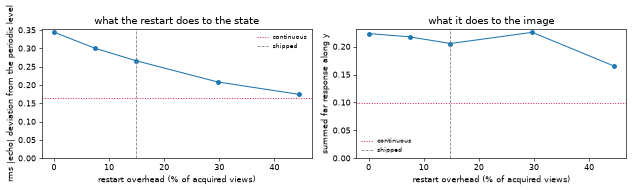

In [17]:
over = np.array([shots * n / len(REP_TABLE) * 100 for n in SWEEP])
fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.2))
for ax, col, name, ref in ((axes[0], 1, 'rms |echo| deviation from the periodic level',
                            np.sqrt(np.mean((cont - 1) ** 2))),
                           (axes[1], 2, 'summed far response along y',
                            far_response(PROFILE['A continuous'])[0])):
    ax.plot(over, [rows[n][col] for n in SWEEP], 'o-', lw=1.3, ms=5)
    ax.axhline(ref, color='crimson', ls=':', lw=1.2, label='continuous')
    ax.axvline(shots * RESTART_DUMMIES / len(REP_TABLE) * 100, color='0.5', ls='--', lw=1.0,
               label='shipped')
    ax.set(xlabel='restart overhead (% of acquired views)', ylabel=name, ylim=(0, None))
    ax.legend(fontsize=7, frameon=False)
axes[0].set_title('what the restart does to the state')
axes[1].set_title('what it does to the image')
fig.tight_layout()

**The two panels do not say the same thing, and that is the result.**

Spending more repetitions on the restart monotonically brings the acquired magnetisation closer to
the periodic state: the deepest excursion rises steadily toward the continuous level and the rms
deviation falls. That is what the restart is for, and it works.

What reaches the image does not follow it. The summed far response moves between 0.165 and 0.226
across the whole sweep with no clear trend -- it is *not* monotone in the restart length, and at 16
dummies it is worse than at none -- while the state metrics beside it improve steadily throughout.
Against a continuous train's 0.100 the segmented acquisition stays between 1.6 and 2.3 times as
bright in the far field whatever the restart policy spends.

That is the finding, not noise in it: whether a per-shot transient becomes visible image structure
depends on **where in the k-space table the disturbed repetitions land**, not only on how large the
disturbance is. Changing the restart length changes which views are acquired while the state
recovers, and that can help or hurt. The next cell shows the same mechanism at a much larger
amplitude.

Two details about the reference line. The continuous train's rms deviation is not zero -- it is
that train's **own opening transient**, 83-odd repetitions out of 3072, and it is the floor the
segmented ones are measured against rather than a defect. Its `min/level` is ~1.0 because a flip
ramp approaches the periodic state from *above*: its transient is an overshoot, while an
interruption produces a dip, so that column reads the deepest downward excursion only.

So the cost is real and the benefit is conditional. `RESTART_DUMMIES = 8` is shipped as an
illustrative point on that curve, not as a recommendation: it lifts the deepest excursion from
0.32 to 0.50 of the periodic level and drops the rms deviation from 0.34 to 0.27, for 15% of the
acquired views. In a cardiac-gated acquisition the imaging window is fixed, so every restart
repetition is a view not acquired, and where to sit on this curve is a protocol decision.

### Where the shot boundaries fall

`SHOT_VIEWS = 53` is the echo train length Morita et al. (2008) report at p.1245, §2.2: a 3D
segmented trueFISP with TR/TE 3.82/1.61 ms, echo train length 53, shot interval 309.5 ms, 107 ms
between shots, matrix 192 x 192, at 1.5 T.

That paper's subject is exactly this question. Its result is that centric and linear orderings of
the *same* segmented sequence give different contrast, because with no dummy pulse "the data of
the k-space center of each shot with centric ordering was sampled from the first RF pulse, while
[that] with linear ordering was sampled after 26 RF pulses were excited". Which views a shot
acquires while its magnetisation is still recovering is the mechanism, not a detail.

The shot *length* is one way that position is set. 53 does not divide 192; 64 would, exactly three
times. The next cell measures both.

  shots of  192 / shot   min/level   rms dev   far sum   max far
        53        3.62       0.316    0.3445     0.223    0.0056
        64        3.00       0.314    0.3581     1.004    0.0897


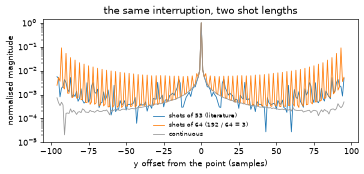

In [18]:
alt = segmented_train(DIAG_DIR / 'shot64.seq', shot_views=64, restart=0)
t64, p64 = echo_train(alt), point_response(alt)
fs64, fm64 = far_response(p64)
b = TRAIN['B segmented, no restart']
fsb, fmb = far_response(PROFILE['B segmented, no restart'])
print(f'{"shots of":>10s}{"192 / shot":>12s}{"min/level":>12s}{"rms dev":>10s}'
      f'{"far sum":>10s}{"max far":>10s}')
print(f'{SHOT_VIEWS:>10d}{REP_MATRIX[1] / SHOT_VIEWS:12.2f}{b.min():12.3f}'
      f'{np.sqrt(np.mean((b - 1) ** 2)):10.4f}{fsb:10.3f}{fmb:10.4f}')
print(f'{64:>10d}{REP_MATRIX[1] / 64:12.2f}{t64.min():12.3f}'
      f'{np.sqrt(np.mean((t64 - 1) ** 2)):10.4f}{fs64:10.3f}{fm64:10.4f}')

fig, ax = plt.subplots(figsize=(6.4, 3.1))
ax.plot(np.arange(REP_NY) - REP_NY // 2, PROFILE['B segmented, no restart'], lw=1.0,
        label=f'shots of {SHOT_VIEWS} (literature)')
ax.plot(np.arange(REP_NY) - REP_NY // 2, p64, lw=1.0, label='shots of 64 (192 / 64 = 3)')
ax.plot(np.arange(REP_NY) - REP_NY // 2, PROFILE['A continuous'], lw=1.0, color='0.6',
        label='continuous')
ax.set(xlabel='y offset from the point (samples)', ylabel='normalised magnitude', yscale='log',
       ylim=(1e-5, 1.5), title='the same interruption, two shot lengths')
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()

Both trains are interrupted the same way and their magnetisation wanders by a comparable amount.
The image response is not comparable. With 64 views per shot the interruptions recur at a period
that divides the 192-line table exactly, so the same disturbance repeats at the same few positions
in `ky` and adds coherently into a small number of discrete off-peak responses. With 53 it does
not divide, the shot boundaries land on different lines on each pass through the table, and the
same amount of disturbed magnetisation is spread thinly instead.

This is why the earlier draft of this notebook reported a dramatic segmentation artifact: it used
a round shot length. The artifact was real, but it was a property of **shot length against matrix
size**, and reporting it as the cost of segmentation in general would have been wrong. Choosing a
shot length that does not divide the phase-encode count is a cheap mitigation that costs no
acquisition time at all -- and it is not available when the window length is dictated by
physiology rather than chosen.

### Off-resonance

During the gap no RF is played, so off-resonance phase accrues freely for 107 ms -- about 25 TRs
worth -- while T1 and T2 relaxation run. Where the magnetisation has drifted to when the next pulse
arrives therefore depends on `Δf`, which is a reason to check the passband rather than assume
resonance is representative of it.

This sweep runs on the **validation** files, and that forces the metric to change. The reduced
protocol holds every variable the per-shot dynamics depends on fixed -- same TR, same 53-view
shots, same 107 ms recovery, same restart policy -- but it is only 256 views long, so the opening
transient is about a third of the train instead of a fortieth. An absolute deviation there would
mostly be measuring the opening ramp.

So the comparison is **differential**: each segmented train is compared with the continuous one
view by view, at the same offset. The opening transient is common to all three and cancels, and
what is left is what the interruptions cost.

rms |echo| difference from the continuous train at the same offset, / its mean level
case                                 0.00 band   0.25 band   0.50 band   0.75 band
B segmented, no restart                 0.2780      0.2206      0.2498      0.2463
C segmented, 8 restart dummies          0.1962      0.1572      0.1954      0.1859
continuous mean |echo|, normalised      1.0000      0.9969      0.9378      0.6626
band edge (first null) at 119 Hz; the gap is 25 TRs of free precession


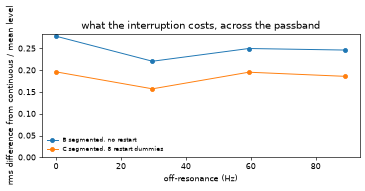

In [19]:
OFFSETS = [0.0, 0.25, 0.5, 0.75]
VAL = {'B segmented, no restart': 'bssfp_3d_validation_segmented',
       f'C segmented, {RESTART_DUMMIES} restart dummies':
           'bssfp_3d_validation_segmented_restart'}


def raw_echoes(stem, df=0.0, tissue='white matter', states=200):
    rows = simulate_wide(SEQ_DIR / f'{stem}.seq', point(df, tissue=tissue), SAMPLES, states=states)
    return np.abs(rows[:, ECHO])


def departure(stem, df=0.0, tissue='white matter', states=200):
    '''rms |echo| difference from the continuous train, over that train's mean level.'''
    base = raw_echoes('bssfp_3d_validation', df, tissue, states)
    seg = raw_echoes(stem, df, tissue, states)
    return np.sqrt(np.mean((seg - base) ** 2)) / base.mean(), base.mean()


off, level = {label: [] for label in VAL}, []
for frac in OFFSETS:
    for label, stem in VAL.items():
        value, mean = departure(stem, frac * NULL_HZ)
        off[label].append(value)
    level.append(mean)

print('rms |echo| difference from the continuous train at the same offset, / its mean level')
print(f'{"case":34s}' + ''.join(f'{f"{f:.2f} band":>12s}' for f in OFFSETS))
for label, curve in off.items():
    print(f'{label:34s}' + ''.join(f'{v:12.4f}' for v in curve))
print(f'{"continuous mean |echo|, normalised":34s}'
      + ''.join(f'{v / level[0]:12.4f}' for v in level))
print(f'band edge (first null) at {NULL_HZ:.0f} Hz; the gap is '
      f'{RECOVERY_S / TR_S:.0f} TRs of free precession')

fig, ax = plt.subplots(figsize=(6.4, 3.1))
for label, curve in off.items():
    ax.plot([f * NULL_HZ for f in OFFSETS], curve, 'o-', lw=1.2, ms=5, label=label)
ax.set(xlabel='off-resonance (Hz)', ylabel='rms difference from continuous / mean level',
       title='what the interruption costs, across the passband', ylim=(0, None))
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()

Two things to read off that. The relative cost of interrupting is **roughly flat across the
passband** -- about 0.22 to 0.28 for the un-prepared train -- rather than growing toward the band
edge, while the signal it is measured against falls to about two-thirds of its on-resonance value
by `0.75` of the way out. And the restart helps **consistently here**, cutting the departure by
between a fifth and a third at every offset -- 29%, 29%, 22% and 25% going outward.

That is a cleaner result than the same restart produced in the image metric above, and for the
reason already established: this measures how far each acquired view sits from where the continuous
train would have put it, while the image additionally depends on *which* views those are.

### Does the restart depend on tissue?

Everything measured so far has been white matter, and the volume below is not. The approach to the
driven state is an eigenvalue of the repetition's transfer matrix, which depends on `T1` and `T2`,
so a fixed number of restart repetitions could plausibly buy very different amounts for tissues
whose time constants differ by a factor of twenty-five.

Asking that question of a balanced sequence means first asking whether the **simulation** can
answer it. bSSFP keeps its coherence pathways alive, and a long `T2` keeps more of them alive for
longer, so every number above rests on a state budget that was chosen for white matter. The budget
is swept before the comparison is read, not after.

In [20]:
BUDGETS = (200, 400, 800)
print(f'{"tissue":14s}{"T1 s":>6s}{"T2 s":>7s}  ' + ''.join(f'{f"{s} states":>13s}' for s in BUDGETS)
      + '   verdict')
CONVERGED = {}
for tissue, props in TISSUES.items():
    seen = [departure(list(VAL.values())[0], 0.0, tissue, s)[0] for s in BUDGETS]
    drift = abs(seen[-1] - seen[-2]) / seen[-1]
    CONVERGED[tissue] = drift < 0.02
    print(f'{tissue:14s}{props["T1"]:6.2f}{props["T2"]:7.3f}  '
          + ''.join(f'{v:13.4f}' for v in seen)
          + f'   {"converged" if CONVERGED[tissue] else f"STILL MOVING ({drift:.0%})"}')
print()
print('the state budget is a property of T2 against TR, not of the acquisition under test')

tissue          T1 s   T2 s     200 states   400 states   800 states   verdict


white matter    0.83  0.080         0.2780       0.2780       0.2780   converged


grey matter     1.33  0.110         0.2537       0.2516       0.2516   converged


CSF             4.00  2.000         0.2816       0.1630       0.1440   STILL MOVING (13%)

the state budget is a property of T2 against TR, not of the acquisition under test


In [21]:
print(f'{"tissue":14s}' + ''.join(f'{lab[:22]:>24s}' for lab in VAL))
for tissue in TISSUES:
    if not CONVERGED[tissue]:
        print(f'{tissue:14s}  excluded -- its departure is still moving at the largest budget '
              f'this notebook runs')
        continue
    row = [departure(stem, 0.0, tissue, BUDGETS[-1])[0] for stem in VAL.values()]
    print(f'{tissue:14s}{row[0]:24.4f}{row[1]:24.4f}'
          f'   ({(row[0] - row[1]) / row[0] * 100:+.0f}% from the restart)')
print()
print(f'{RESTART_DUMMIES} repetitions is {RESTART_DUMMIES * TR_S * 1e3:.0f} ms')

tissue          B segmented, no restar  C segmented, 8 restart


white matter                    0.2780                  0.1962   (+29% from the restart)


grey matter                     0.2516                  0.2067   (+18% from the restart)
CSF             excluded -- its departure is still moving at the largest budget this notebook runs

8 repetitions is 34 ms


**The question the sweep was asked could only be answered for part of it.** White matter and grey
matter settle by a few hundred states and are reported; CSF's departure is still moving by tens of
percent between budgets, having changed sign more than once along the way, so no number for it is
quoted. It is excluded for the same reason Section 1 excludes it from settling claims -- a `T2` of
two seconds against a 4.2 ms TR is a different simulation problem, not a harder version of this one.

For the two that do converge, the restart helps by a broadly similar fraction -- so **the obvious
explanation for the volume result below was measured and did not survive**, which is worth more
here than the hypothesis would have been.

### What the segmented volumes look like

Section 3 reconstructed the continuous acquisition. The same reduced protocol, interrupted.

B segmented, no restart            summed |difference| from continuous:  33.3% of its signal


C segmented, 8 restart dummies     summed |difference| from continuous:  32.9% of its signal

note the gap: the restart cut the per-view departure by a fifth to a quarter for both
tissues that converged above, and moves this volume figure by well under a percentage
point.  The two are not the same measurement -- this one is taken after reconstruction,
so it depends on where the residual lands in k-space and on its phase, neither of which
a per-view magnitude carries.  Which of those dominates is not resolved here, and the
volume also contains CSF, whose contribution this notebook cannot price.


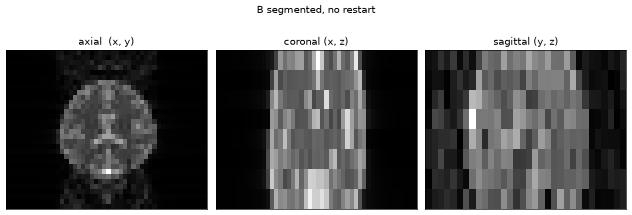

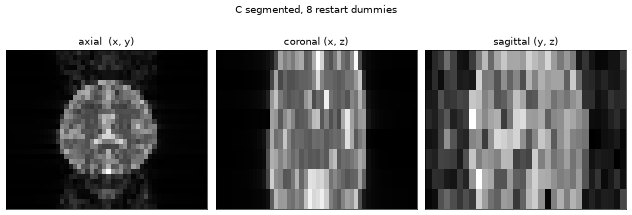

In [22]:
if BRAIN_IMAGES:
    for label, stem in VAL.items():          # VAL is the two interrupted trains; A is section 3
        volume = reconstruct(simulate(SEQ_DIR / f'{stem}.seq', brain.build()))[1]
        three_planes(np.abs(volume), label)
        rel = np.abs(np.abs(volume) - np.abs(vol_cont)).sum() / np.abs(vol_cont).sum()
        print(f'{label:34s} summed |difference| from continuous: {rel * 100:5.1f}% of its signal')
    print()
    print('note the gap: the restart cut the per-view departure by a fifth to a quarter for both')
    print('tissues that converged above, and moves this volume figure by well under a percentage')
    print('point.  The two are not the same measurement -- this one is taken after reconstruction,')
    print('so it depends on where the residual lands in k-space and on its phase, neither of which')
    print('a per-view magnitude carries.  Which of those dominates is not resolved here, and the')
    print('volume also contains CSF, whose contribution this notebook cannot price.')
else:
    print('BRAIN_IMAGES is off -- the point-object numbers above are the quantitative result')

### What remains protocol-dependent

The point response along `y` is a point response, not a resolution metric: it says how much signal
from one location appears at other locations, and nothing about how finely two nearby objects can
be told apart. At this shot length the two halves of it part company. The **largest** single
off-peak sample is nearly the same for all three trains -- 0.0055 continuous against 0.0056 and
0.0060 segmented -- while the **summed** off-peak magnitude roughly doubles, 0.100 against 0.223
and 0.206. The interruption adds distant response along `y` that is spread thinly across many
samples rather than concentrated in a few. At 64 views per shot it concentrates instead, and then
the largest sample rises sixteenfold.

What this section establishes is a shape, not a number to carry elsewhere. Nothing here transfers
to another protocol without re-measuring, because the outcome turns on all of:

```text
shot / tau             how many repetitions a shot holds against the transient decay length,
                       which is set by the eigenvalues of the repetition's transfer matrix
recovery / T1          how much longitudinal magnetisation returns during the gap
recovery / T2          how much transverse magnetisation is left to be re-phased
df * recovery          how much off-resonance phase accrues while no RF constrains it
restart policy         how many repetitions, at what flip angle, at what encoding
RF phase policy        whether the alternation continues across the gap or resets
shot boundary in k     which lines are acquired while the state is still recovering --
                       the difference between the two shot lengths above
```

A segmented acquisition is characterised by this set, and the headline numbers in this notebook
belong to one point in it: 53-view shots, 107 ms recovery, white matter at 3 T, a 0/pi phase
alternation carried unbroken across the gap, and shot boundaries falling where 53-view shots land
in a bidirectional sequential order over 192 lines.